TASK1

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

fx = pd.read_csv('./data_safe_copy.csv')

fx.set_index("Date", inplace=True)
fx.sort_index(inplace=True)

numeric_check = fx.apply(lambda collumn: pd.api.types.is_numeric_dtype(collumn))
print(numeric_check)

fx.head()
fx.tail()

EURUSD    True
GBPUSD    True
PLNUSD    True
USDPLN    True
USDJPY    True
AUDUSD    True
NZDUSD    True
USDCAD    True
USDCHF    True
EURPLN    True
GBPPLN    True
dtype: bool


,EURUSD,GBPUSD,PLNUSD,USDPLN,USDJPY,AUDUSD,NZDUSD,USDCAD,USDCHF,EURPLN,GBPPLN
Date,,,,,,,,,,,
2026-01-26,1.18777,1.36768,0.282362,3.54155,154.1550,0.69100,0.59697,1.37115,0.77720,4.20655,4.84370
2026-01-27,1.20426,1.38461,0.286789,3.48689,152.3020,0.70092,0.60433,1.35758,0.76114,4.19912,4.82798
2026-01-28,1.19562,1.38024,0.284316,3.51721,153.4235,0.70384,0.60594,1.35621,0.76859,4.20524,4.85459
2026-01-29,1.19695,1.38095,0.284600,3.51370,153.0050,0.70497,0.60751,1.34872,0.76476,4.20572,4.85224
2026-01-30,1.18534,1.36839,0.281465,3.55284,154.7785,0.69637,0.60212,1.36162,0.77302,4.21132,4.86167


TASK2

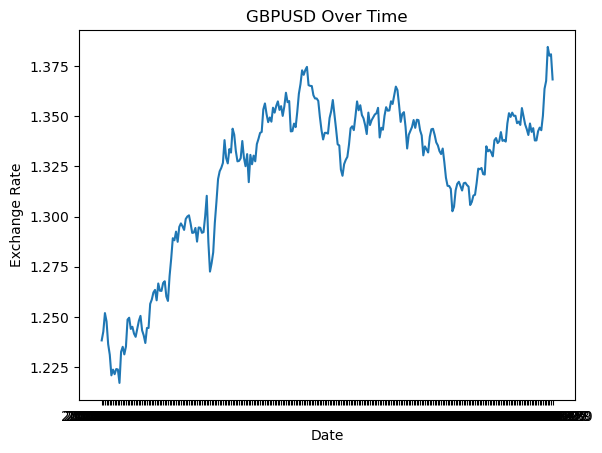

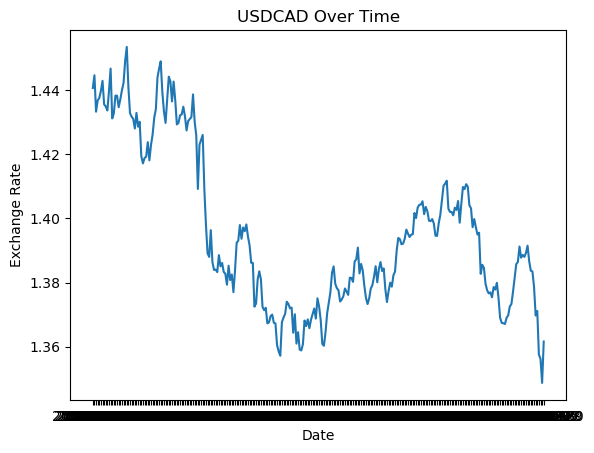

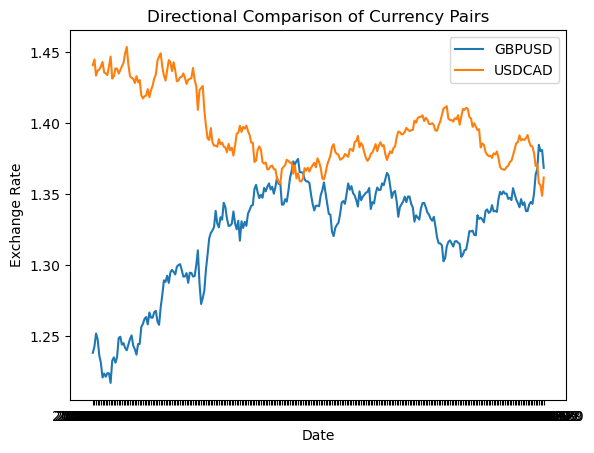

In [16]:
pair1 = 'GBPUSD'
pair2 = 'USDCAD'

#1
plt.figure()
plt.plot(fx.index, fx[pair1])
plt.title(f"{pair1} Over Time")
plt.xlabel("Date")
plt.ylabel("Exchange Rate")
plt.show()

#2
plt.figure()
plt.plot(fx.index, fx[pair2])
plt.title(f"{pair2} Over Time")
plt.xlabel("Date")
plt.ylabel("Exchange Rate")
plt.show()

#&
plt.figure()
plt.plot(fx.index, fx[pair1], label=pair1)
plt.plot(fx.index, fx[pair2], label=pair2)
plt.title("Directional Comparison of Currency Pairs")
plt.xlabel("Date")
plt.ylabel("Exchange Rate")
plt.legend()
plt.show()


TASK3

In [26]:

rolling_window_size = 7


fx[f"{pair1}_roll_mean"] = fx[pair1].rolling(window=rolling_window_size).mean()
fx[f"{pair1}_roll_std"] = fx[pair1].rolling(window=rolling_window_size).std()


fx[f"{pair2}_roll_mean"] = fx[pair2].rolling(window=rolling_window_size).mean()
fx[f"{pair2}_roll_std"] = fx[pair2].rolling(window=rolling_window_size).std()

rolling_cols = [
    f"{pair1}_roll_mean", f"{pair1}_roll_std",
    f"{pair2}_roll_mean", f"{pair2}_roll_std"
]

print("\nFirst 10 rows:")
print(fx[rolling_cols].head(10))

print("\nMissing values")
print(fx[rolling_cols].isna().sum())



First 10 rows:
            GBPUSD_roll_mean  GBPUSD_roll_std  USDCAD_roll_mean  \
Date                                                              
2025-01-02               NaN              NaN               NaN   
2025-01-03               NaN              NaN               NaN   
2025-01-06               NaN              NaN               NaN   
2025-01-07               NaN              NaN               NaN   
2025-01-08               NaN              NaN               NaN   
2025-01-09               NaN              NaN               NaN   
2025-01-10          1.238401         0.010432          1.439394   
2025-01-13          1.236320         0.011826          1.438669   
2025-01-14          1.233284         0.012624          1.437276   
2025-01-15          1.229299         0.009881          1.437331   

            USDCAD_roll_std  
Date                         
2025-01-02              NaN  
2025-01-03              NaN  
2025-01-06              NaN  
2025-01-07              NaN  

TASK4

In [25]:
fx['baseline_pred'] = fx[pair1].shift(1)

fx['abs_error'] = (fx[pair1] - fx['baseline_pred']).abs()

abs_error_mean = fx['abs_error'].mean()
print(abs_error_mean)

validation_check = (fx['baseline_pred'].notna().sum() == len(fx)-1)

0.004556810035842285


TASK5

In [43]:
report_dictionary = {
    'currency_pair': [pair1,pair2],
    'rolling_window_size': rolling_window_size,
    'abs_error_mean': abs_error_mean,
    'dataset_date_range': (fx.index.min(), fx.index.max())
}

print(*report_dictionary.items(), sep="\n")

explicit_check = (rolling_window_size == report_dictionary['rolling_window_size'])

('currency_pair', ['GBPUSD', 'USDCAD'])
('rolling_window_size', 7)
('abs_error_mean', np.float64(0.004556810035842285))
('dataset_date_range', ('2025-01-02', '2026-01-30'))
